In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [7]:
dataset = pd.read_csv('housepricing.csv')
dataset.head(3)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062


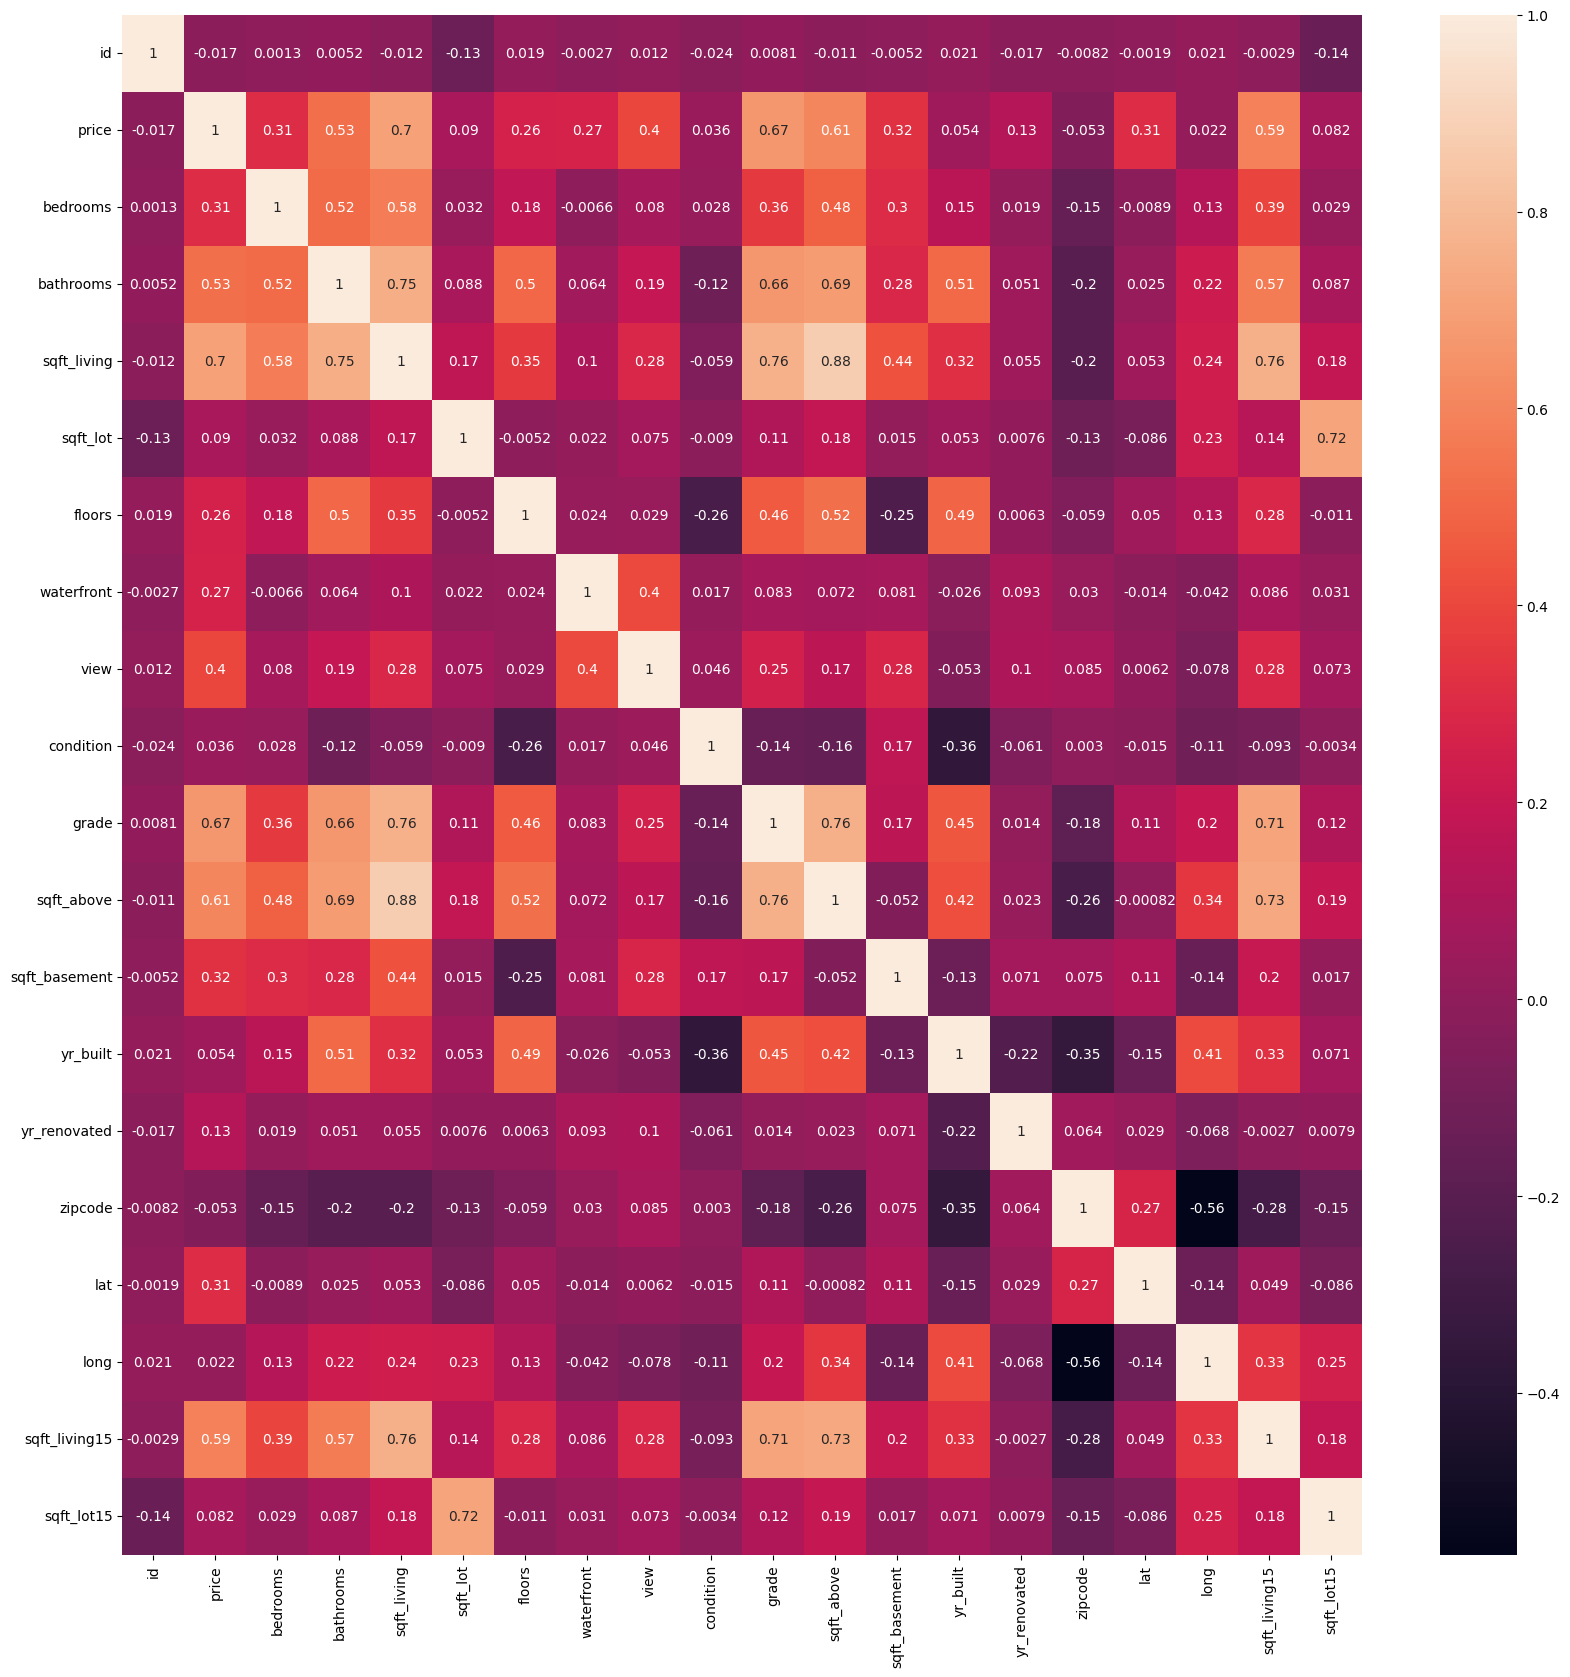

In [10]:
plt.figure(figsize=(20,20))
sns.heatmap(dataset.corr(numeric_only=True), annot=True)
plt.show()


In [12]:
x = dataset.iloc[:, :-1]
y = dataset["price"]

In [16]:
x.dtypes

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
dtype: object

In [22]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
x = pd.DataFrame(sc.fit_transform(x), columns=x.columns)


In [23]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [24]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge

In [28]:
lr = LinearRegression()
lr.fit(x_train, y_train)
lr.score(x_test, y_test)*100

100.0

In [29]:
lr.coef_

array([ 1.00755105e-10,  3.67118703e+05, -1.30852205e-11,  1.39967581e-10,
        1.33394493e-10,  2.68972731e-11, -1.17425429e-10,  5.17640391e-11,
        6.33050087e-11,  9.39784522e-12,  8.86940266e-11, -1.16126950e-12,
       -5.12667837e-11,  1.34200556e-11, -1.58855592e-10,  1.45018959e-11,
        1.72968836e-10, -1.09139364e-10,  1.15505827e-10, -1.09139364e-11,
       -2.91038305e-11])

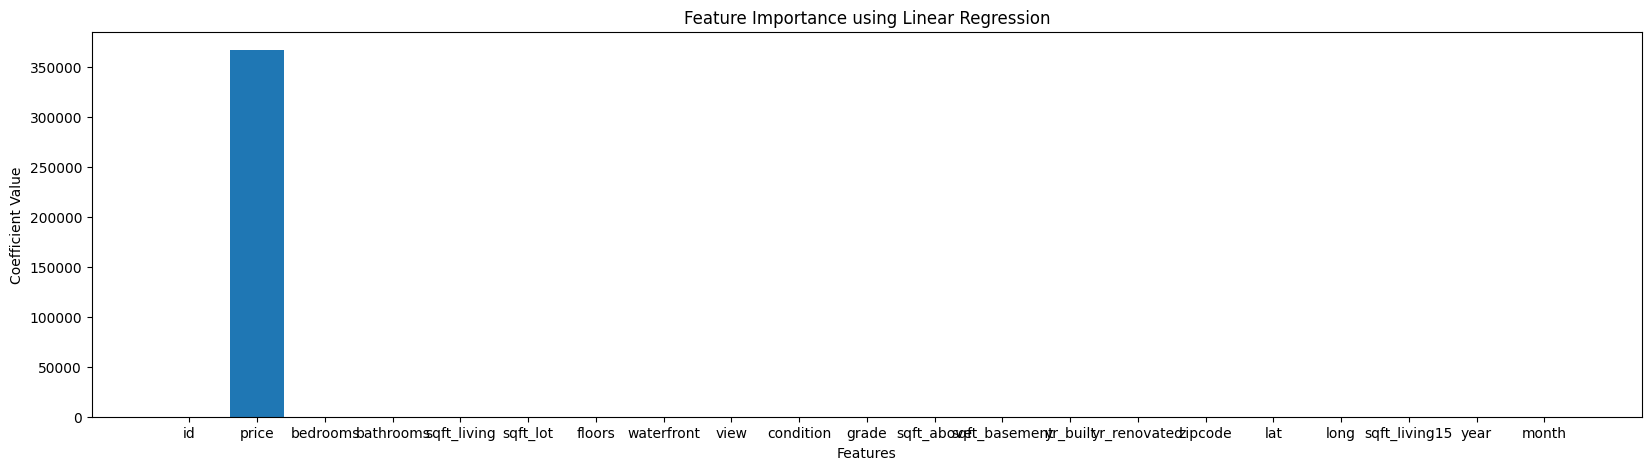

In [36]:
plt.figure(figsize=(20,5))
plt.bar(x.columns, lr.coef_)
plt.title("Feature Importance using Linear Regression")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.show()

In [30]:
x.columns


Index(['id', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'year', 'month'],
      dtype='object')

In [47]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

In [37]:
# Lasso Regression

In [59]:
la = Lasso(alpha = 5)
la.fit(x_train, y_train)
la.score(x_test, y_test)*100

99.99999967050972

In [60]:
print(mean_squared_error(y_test, la.predict(x_test)))
print(mean_absolute_error(y_test, la.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test, la.predict(x_test))))

498.1125638192823
15.588671872257219
22.318435514598292


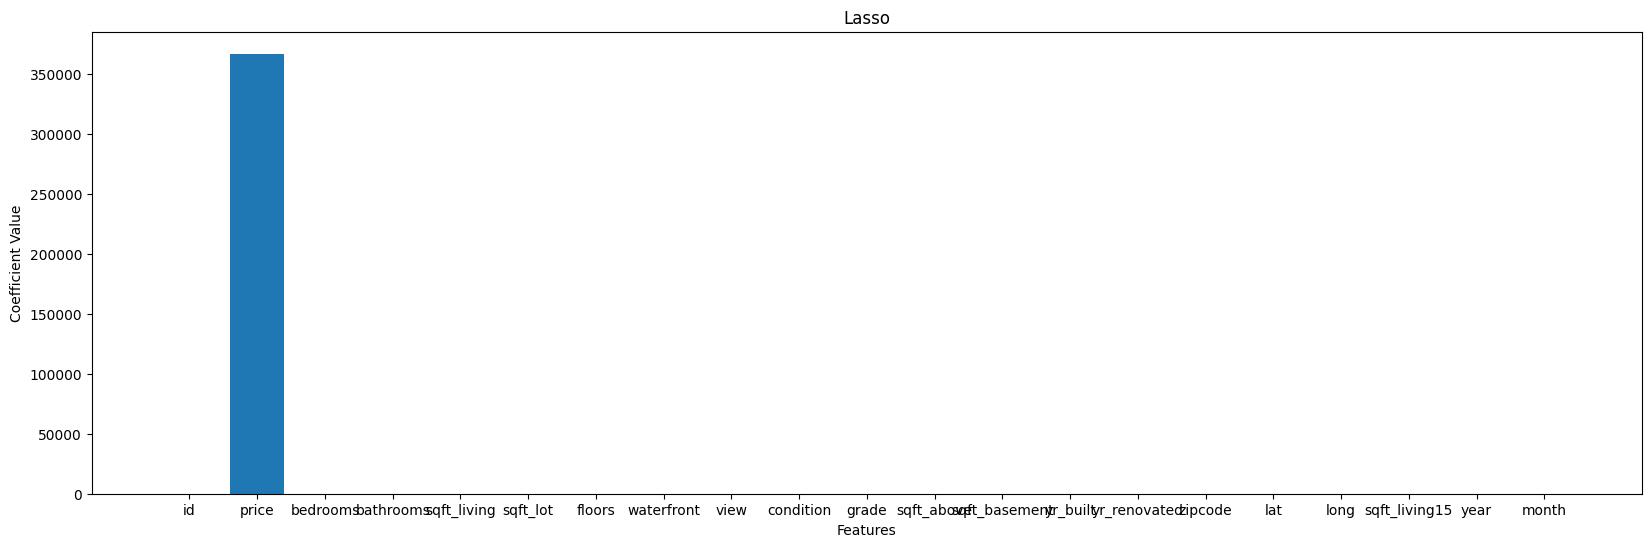

In [61]:
plt.figure(figsize=(20,6))
plt.bar(x.columns, la.coef_)
plt.title("Lasso")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")     
plt.show()

In [44]:
# Ridge Regression

In [45]:
ri = Ridge(alpha = 10)
ri.fit(x_train, y_train)
ri.score(x_test, y_test)*100

99.999882339563

In [54]:
print(mean_squared_error(y_test, ri.predict(x_test)))
print(mean_absolute_error(y_test, ri.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test, ri.predict(x_test))))

177875.18028864925
252.5117286860342
421.75251070817495


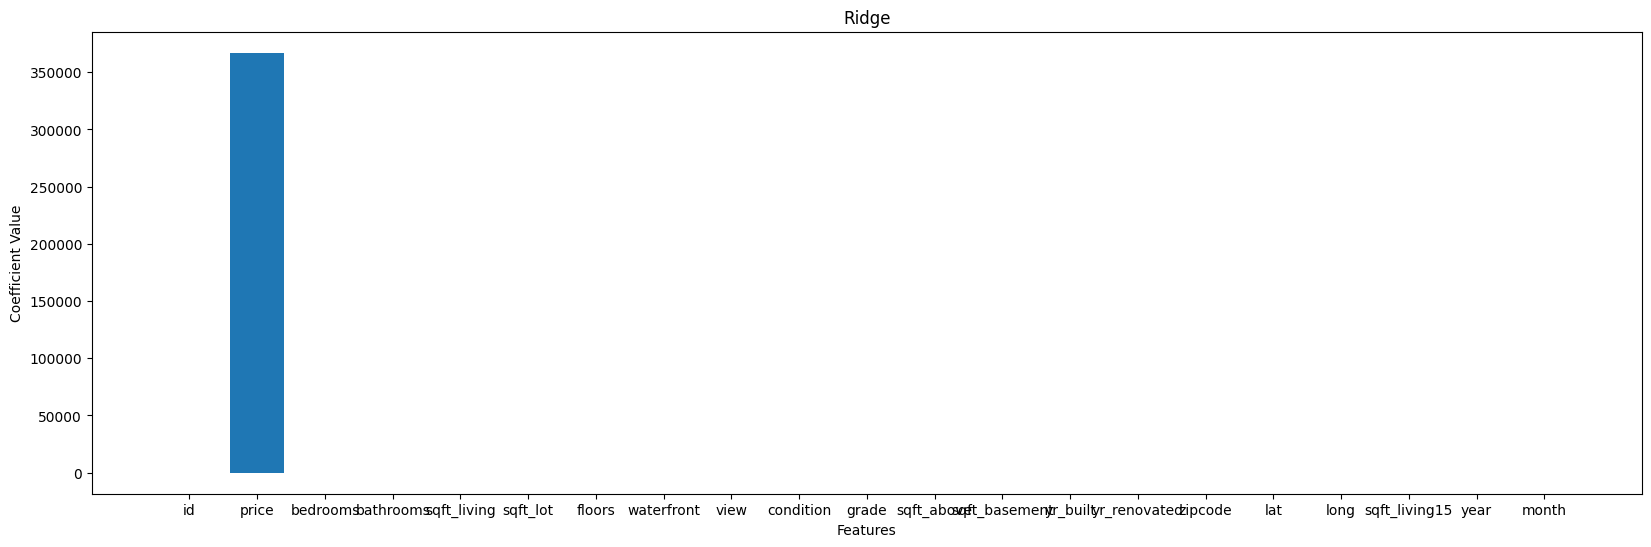

In [46]:
plt.figure(figsize=(20,6))
plt.bar(x.columns, la.coef_)
plt.title("Ridge")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")     
plt.show()

In [58]:
df = pd.DataFrame({
    "col_name": x.columns,"Linear Regression": lr.coef_, "Lasso": la.coef_, "Ridge": ri.coef_
})
df

,col_name,Linear Regression,Lasso,Ridge
0,id,1.007551e-10,-0.913233,-6.998946
1,price,3.671187e+05,367111.169289,366389.343292
2,bedrooms,-1.308522e-11,0.272386,-62.863110
3,bathrooms,1.399676e-10,11.259110,68.794846
4,sqft_living,1.333945e-10,3.494046,159.682349
5,sqft_lot,2.689727e-11,0.000000,-7.470228
6,floors,-1.174254e-10,3.844034,8.796382
7,waterfront,5.176404e-11,3.452920,96.529258
8,view,6.330501e-11,-6.751888,81.238152
9,condition,9.397845e-12,-3.833970,33.167147
